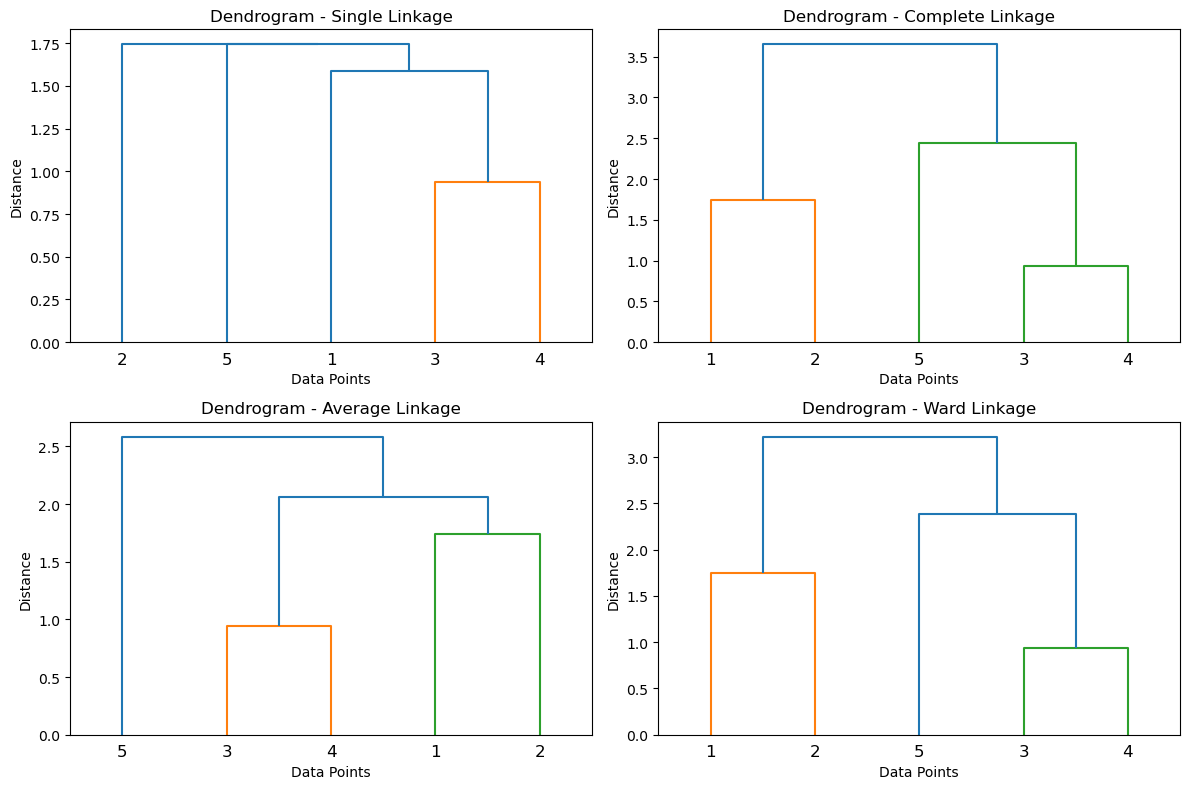

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: Simple dataset
data = pd.DataFrame({
    'x': [3, 3, 5, 6, 6],
    'y': [2, 5, 3, 4, 7]
}, index=['1', '2', '3', '4', '5'])

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Step 3: Different Linkage Methods
methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(12,8))

for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    dendrogram(linkage(X_scaled, method=method), labels=data.index.tolist())
    plt.title(f"Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()


# Hierarchical Clustering on Titanic Dataset

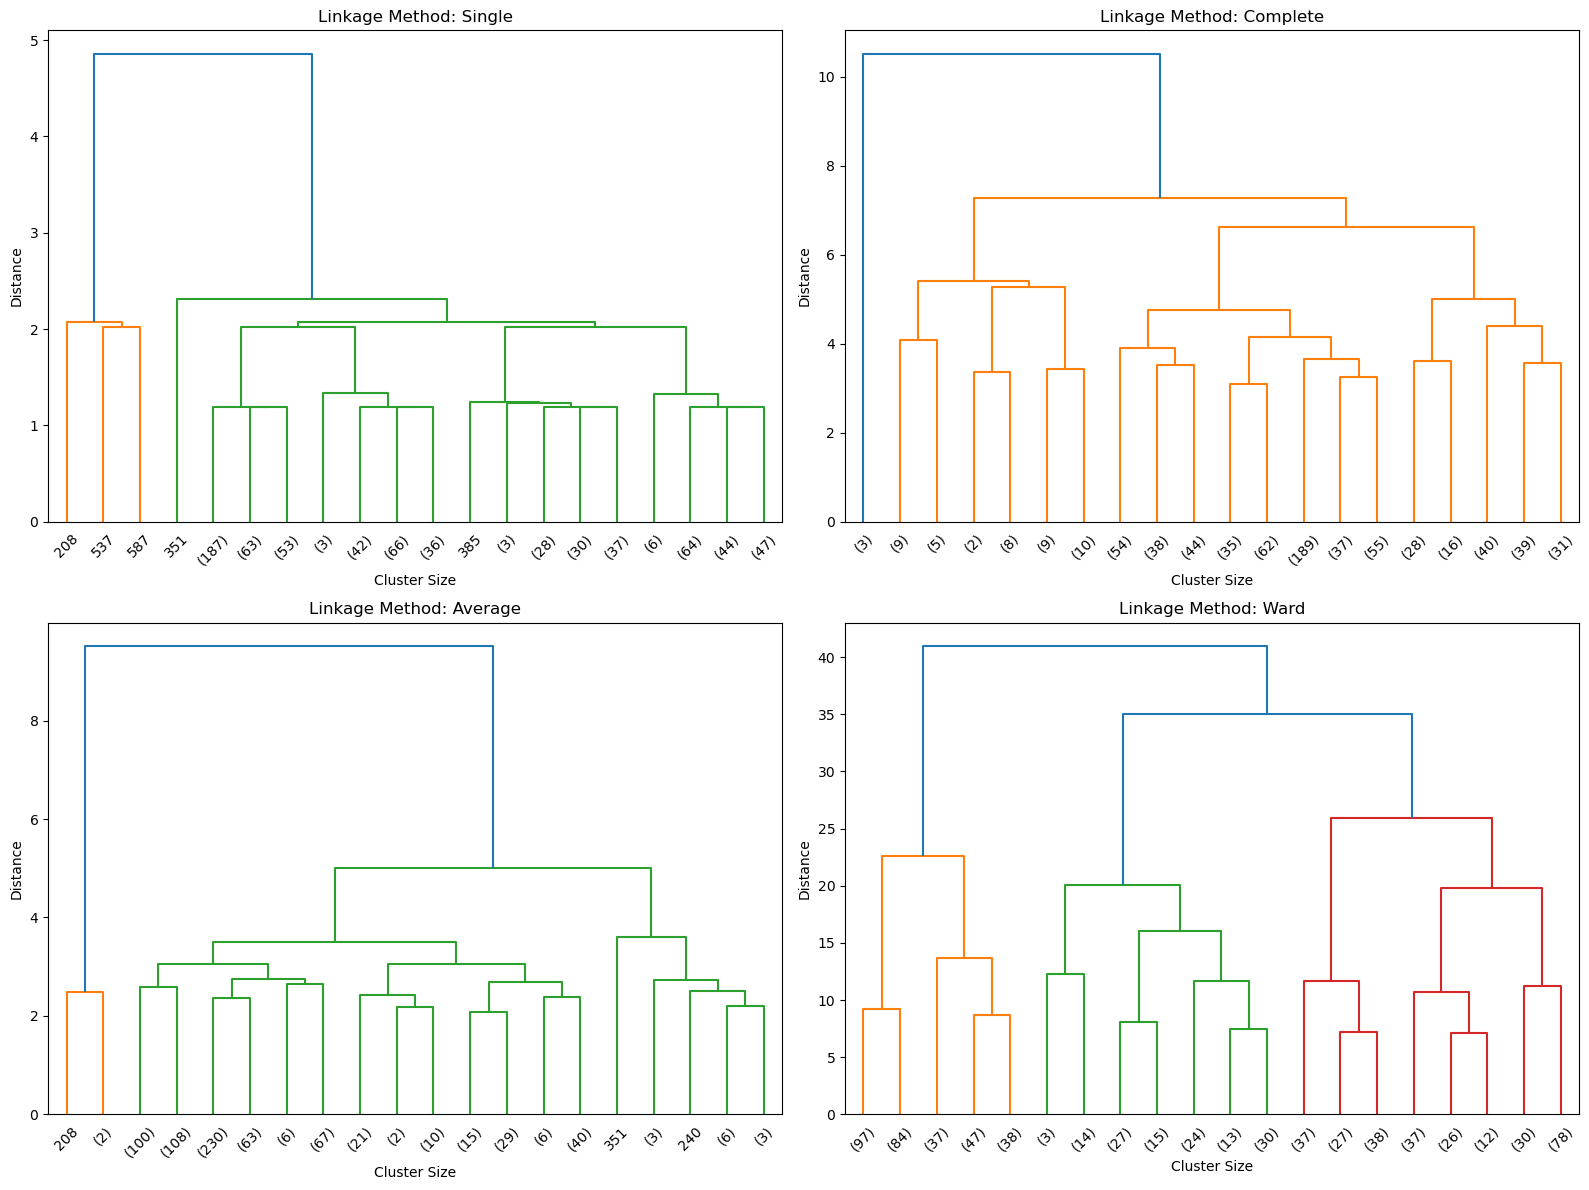

In [4]:
# Hierarchical Clustering on Titanic Dataset with Different Linkage Methods
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load Titanic dataset
# ---------------------------
titanic = sns.load_dataset("titanic")

# Select useful numerical + categorical columns
df = titanic[['pclass', 'age', 'fare', 'sex', 'alone']].dropna()

# Convert categorical variable 'sex' to numeric (male=1, female=0)
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# ---------------------------
# 2. Standardize numeric features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ---------------------------
# 3. Perform hierarchical clustering with 4 linkages
# ---------------------------
linkage_methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(16, 12))
for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
    plt.title(f"Linkage Method: {method.title()}")
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()


# Titanic Hierarchical Clustering + Cluster Analysis

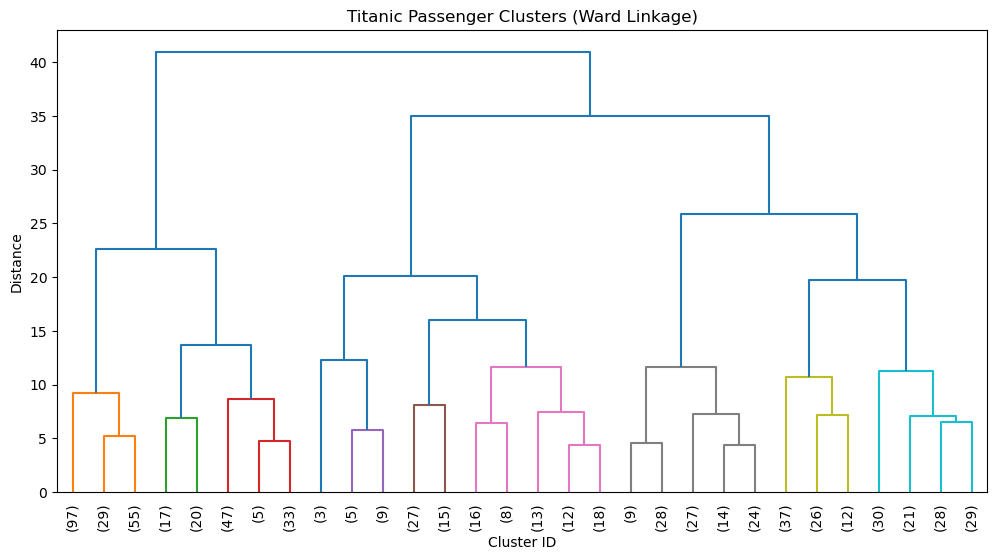


Cluster Survival Summary:
   Cluster  Survival Rate  Passengers
0        1       0.165017         303
1        2       0.769841         126
2        3       0.501754         285


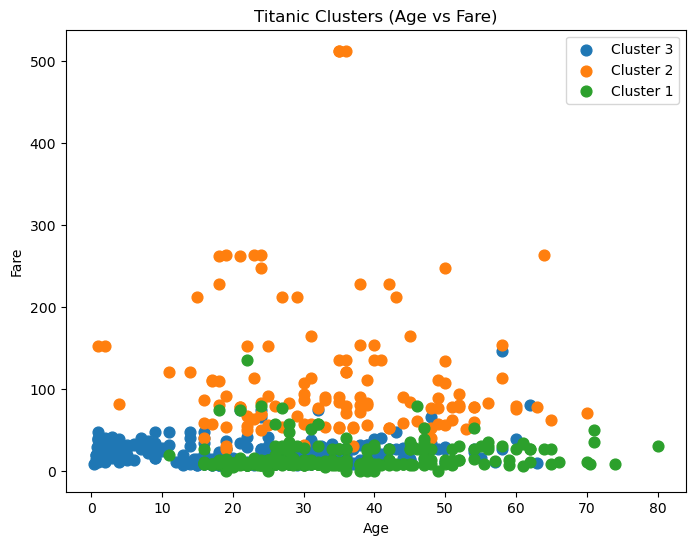

In [5]:
# Hierarchical Clustering on Titanic Dataset + Cluster Analysis
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load Titanic dataset
# ---------------------------
titanic = sns.load_dataset("titanic")

# Select relevant features
df = titanic[['survived', 'pclass', 'age', 'fare', 'sex', 'alone']].dropna()

# Encode categorical variable
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# ---------------------------
# 2. Scale features for clustering
# ---------------------------
features = ['pclass', 'age', 'fare', 'sex', 'alone']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# ---------------------------
# 3. Perform Hierarchical Clustering (Ward method)
# ---------------------------
Z = linkage(X_scaled, method='ward')

# ---------------------------
# 4. Create dendrogram with colored clusters
# ---------------------------
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    color_threshold=12,  # adjust to control cluster coloring
)
plt.title("Titanic Passenger Clusters (Ward Linkage)")
plt.xlabel("Cluster ID")
plt.ylabel("Distance")
plt.show()

# ---------------------------
# 5. Assign cluster labels
# ---------------------------
# Choose the number of clusters (say 3 for demonstration)
df['Cluster'] = fcluster(Z, t=3, criterion='maxclust')

# ---------------------------
# 6. Analyze survival rates within each cluster
# ---------------------------
cluster_summary = df.groupby('Cluster')['survived'].agg(['mean', 'count']).reset_index()
cluster_summary.rename(columns={'mean': 'Survival Rate', 'count': 'Passengers'}, inplace=True)

print("\nCluster Survival Summary:")
print(cluster_summary)

# ---------------------------
# 7. Visualize clusters by average Age vs Fare
# ---------------------------
plt.figure(figsize=(8,6))
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['age'], cluster_data['fare'], label=f"Cluster {cluster}", s=60)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Clusters (Age vs Fare)")
plt.legend()
plt.show()


# Ward vs Complete Linkage Comparison on Titanic Dataset

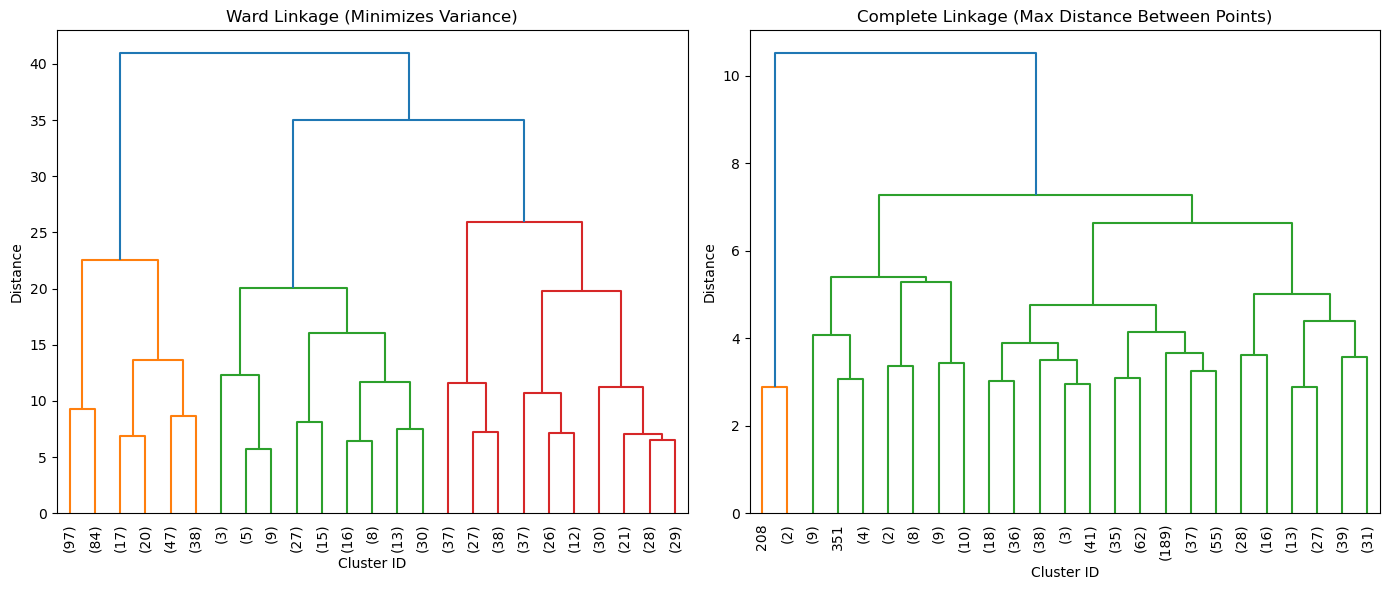


=== Ward Linkage Cluster Summary ===
   Cluster_Ward      mean  count
0             1  0.165017    303
1             2  0.769841    126
2             3  0.501754    285

=== Complete Linkage Cluster Summary ===
   Cluster_Complete      mean  count
0                 1  1.000000      3
1                 2  0.813953     43
2                 3  0.377246    668


In [6]:
# Titanic Hierarchical Clustering - Ward vs Complete Comparison
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load and preprocess data
# ---------------------------
titanic = sns.load_dataset("titanic")

df = titanic[['survived', 'pclass', 'age', 'fare', 'sex', 'alone']].dropna()
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

features = ['pclass', 'age', 'fare', 'sex', 'alone']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# ---------------------------
# 2. Perform Hierarchical Clustering with different linkages
# ---------------------------
Z_ward = linkage(X_scaled, method='ward')
Z_complete = linkage(X_scaled, method='complete')

# ---------------------------
# 3. Plot dendrograms side by side
# ---------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
dendrogram(Z_ward, truncate_mode='lastp', p=25, leaf_rotation=90., leaf_font_size=10.)
plt.title("Ward Linkage (Minimizes Variance)")
plt.xlabel("Cluster ID")
plt.ylabel("Distance")

plt.subplot(1, 2, 2)
dendrogram(Z_complete, truncate_mode='lastp', p=25, leaf_rotation=90., leaf_font_size=10.)
plt.title("Complete Linkage (Max Distance Between Points)")
plt.xlabel("Cluster ID")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# ---------------------------
# 4. Assign clusters (3 clusters for simplicity)
# ---------------------------
df['Cluster_Ward'] = fcluster(Z_ward, t=3, criterion='maxclust')
df['Cluster_Complete'] = fcluster(Z_complete, t=3, criterion='maxclust')

# ---------------------------
# 5. Compare survival rate across linkage methods
# ---------------------------
summary_ward = df.groupby('Cluster_Ward')['survived'].agg(['mean', 'count']).reset_index()
summary_complete = df.groupby('Cluster_Complete')['survived'].agg(['mean', 'count']).reset_index()

print("\n=== Ward Linkage Cluster Summary ===")
print(summary_ward)

print("\n=== Complete Linkage Cluster Summary ===")
print(summary_complete)


# Titanic Hierarchical Clustering - 3D Visualization for Ward vs Complete Linkage

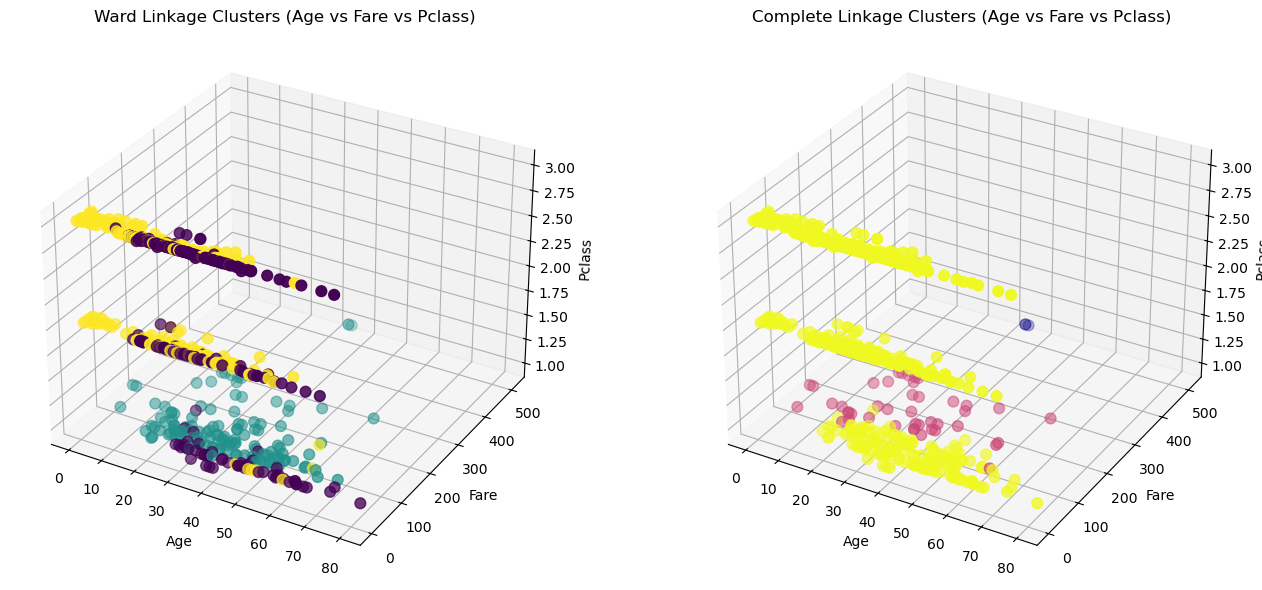

In [2]:

import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# 1. Load and preprocess Titanic dataset
# ---------------------------
titanic = sns.load_dataset("titanic")

df = titanic[['survived', 'pclass', 'age', 'fare', 'sex', 'alone']].dropna()
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

features = ['pclass', 'age', 'fare', 'sex', 'alone']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# ---------------------------
# 2. Perform Hierarchical Clustering (Ward and Complete)
# ---------------------------
Z_ward = linkage(X_scaled, method='ward')
Z_complete = linkage(X_scaled, method='complete')

# Create 3 clusters for comparison
df['Cluster_Ward'] = fcluster(Z_ward, t=3, criterion='maxclust')
df['Cluster_Complete'] = fcluster(Z_complete, t=3, criterion='maxclust')

# ---------------------------
# 3. 3D Visualization Setup
# ---------------------------
fig = plt.figure(figsize=(14, 6))

# --- Ward Linkage ---
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(df['age'], df['fare'], df['pclass'],
                  c=df['Cluster_Ward'], cmap='viridis', s=60)
ax1.set_title("Ward Linkage Clusters (Age vs Fare vs Pclass)")
ax1.set_xlabel("Age")
ax1.set_ylabel("Fare")
ax1.set_zlabel("Pclass")

# --- Complete Linkage ---
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(df['age'], df['fare'], df['pclass'],
                  c=df['Cluster_Complete'], cmap='plasma', s=60)
ax2.set_title("Complete Linkage Clusters (Age vs Fare vs Pclass)")
ax2.set_xlabel("Age")
ax2.set_ylabel("Fare")
ax2.set_zlabel("Pclass")

plt.tight_layout()
plt.show()
